In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract ZIP file
from pathlib import Path
import zipfile

zip_path = Path("/content/drive/MyDrive/MMA3001_Project/dataset/pork_rasher_v1.zip")
extract_path = Path("/content/pork_rasher_v1")

if not zip_path.exists():
    print("Error: ZIP file not found at the specified path.")
    print("Please check if the file exists and if Google Drive is mounted correctly.")
else:
    extract_path.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully!")

    # Display the extracted folder structure
    print("\nExtracted files and folders:")
    for item in sorted(extract_path.iterdir()):
        print(item.name)

Dataset extracted successfully!

Extracted files and folders:
README.dataset.txt
README.roboflow.txt
data.yaml
test
train
valid


In [ ]:
# 2. read data.yaml, confirmation for 4 defect classes
import yaml

# locate the dataset configuration
dataset_path = Path("/content/pork_rasher_v1")
yaml_path = dataset_path / "data.yaml"

# read the configuration
with open(yaml_path, "r") as file:
  config = yaml.safe_load(file)

# Display the configuration
print("Dataset configuration:\n")
for key, value in config.items():
  print(f"{key}: {value}")

Dataset configuration:

train: ../train/images
val: ../valid/images
test: ../test/images
nc: 4
names: ['loose-meat', 'packaging-error', 'twisted-meat', 'unsealed']
roboflow: {'workspace': 'hello-2aqe0', 'project': 'pork-rasher-error-packaging', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/hello-2aqe0/pork-rasher-error-packaging/dataset/1'}


In [ ]:
# 3. count images and annotations, so we know if the data split is reasonable
from collections import Counter

dataset_path = Path("/content/pork_rasher_v1")
class_names = config["names"]

# check each dataset split
for split in ["train", "valid", "test"]:
  image_dir = dataset_path / split / "images"
  label_dir = dataset_path / split / "labels"

  # count images
  images = [
      p for p in image_dir.iterdir()
      if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
  ]

  # count bounding box annotations
  class_counts = Counter()
  for label_path in label_dir.iterdir():
    with open(label_path, "r") as file:
      for line in file:
        if line.strip():
          class_id = int(line.split()[0])
          class_counts[class_id] += 1

  # display results
  print(f"\n======{split.upper()} SET======")
  print("Total images:", len(images))

  for class_id, class_name in enumerate(class_names):
    print(f"{class_name}: {class_counts[class_id]}")


======TRAIN SET======
Total images: 1944
loose-meat: 139
packaging-error: 937
twisted-meat: 91
unsealed: 1110

======VALID SET======
Total images: 120
loose-meat: 5
packaging-error: 57
twisted-meat: 5
unsealed: 88

======TEST SET======
Total images: 80
loose-meat: 3
packaging-error: 37
twisted-meat: 7
unsealed: 52


In [ ]:
# 4. Create cleaned dataset to avoid source-image leakage
import shutil

original = dataset_path
clean = Path("/content/pork_rasher_dataset_clean")

# Copy original dataset into a fresh folder
shutil.rmtree(clean, ignore_errors=True)
shutil.copytree(original, clean)

def source_ids(split):
    return {
        p.name.split(".rf.")[0]
        for p in (clean / split / "images").glob("*.jpg")
    }

# Remove overlapping images and their labels
for split, blocked in [
    ("train", source_ids("valid") | source_ids("test")),
    ("valid", source_ids("test"))
]:
    for image in (clean / split / "images").glob("*.jpg"):
        if image.name.split(".rf.")[0] in blocked:
            image.unlink()
            (clean / split / "labels" / f"{image.stem}.txt").unlink()

# Update YOLO dataset configuration
config.update({
    "path": str(clean),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images"
})

(clean / "data.yaml").write_text(yaml.safe_dump(config))

# Confirm no shared source identifiers
assert not (
    source_ids("train") & source_ids("valid")
    or source_ids("train") & source_ids("test")
    or source_ids("valid") & source_ids("test")
)

print("No overlapping source identifiers between dataset splits.")

No overlapping source identifiers between dataset splits.


In [ ]:
# 5. Verify cleaned images and annotations

for split in ["train", "valid", "test"]:

    images = list((clean / split / "images").glob("*.jpg"))
    counts = Counter()

    for image in images:
        label = clean / split / "labels" / f"{image.stem}.txt"
        assert label.exists(), f"Missing label: {image.name}"

        for line in label.read_text().splitlines():
            if not line.strip():
                continue

            values = list(map(float, line.split()))
            assert len(values) == 5, f"Invalid label: {label.name}"

            class_id, x, y, w, h = values

            # Verify class ID and bounding-box coordinates
            assert class_id.is_integer() and 0 <= class_id < len(class_names)
            assert w > 0 and h > 0
            assert 0 <= x - w/2 <= x + w/2 <= 1
            assert 0 <= y - h/2 <= y + h/2 <= 1

            counts[int(class_id)] += 1

    # Display final results
    print(f"\n{split.upper()}: {len(images)} images")
    for i, name in enumerate(class_names):
        print(f"{name}: {counts[i]}")

print("\nAnnotation verification complete.")


TRAIN: 1935 images
loose-meat: 139
packaging-error: 931
twisted-meat: 91
unsealed: 1107

VALID: 119 images
loose-meat: 5
packaging-error: 57
twisted-meat: 5
unsealed: 87

TEST: 80 images
loose-meat: 3
packaging-error: 37
twisted-meat: 7
unsealed: 52

Annotation verification complete.


In [ ]:
%pip install -q ultralytics
# 6. train first YOLOv8 model
from ultralytics import YOLO

# Load pretrained YOLOv8 Nano
model = YOLO("yolov8n.pt")

# Train the first baseline model using the V1 dataset
results = model.train(
    data=str(clean / "data.yaml"),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,
    project="/content/drive/MyDrive/MMA3001_Project/model_runs",
    name="yolov8n_v1_baseline"
)

print("Training results saved to:", results.save_dir)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pork_rasher_dataset_clean/data.yaml, degrees=0.

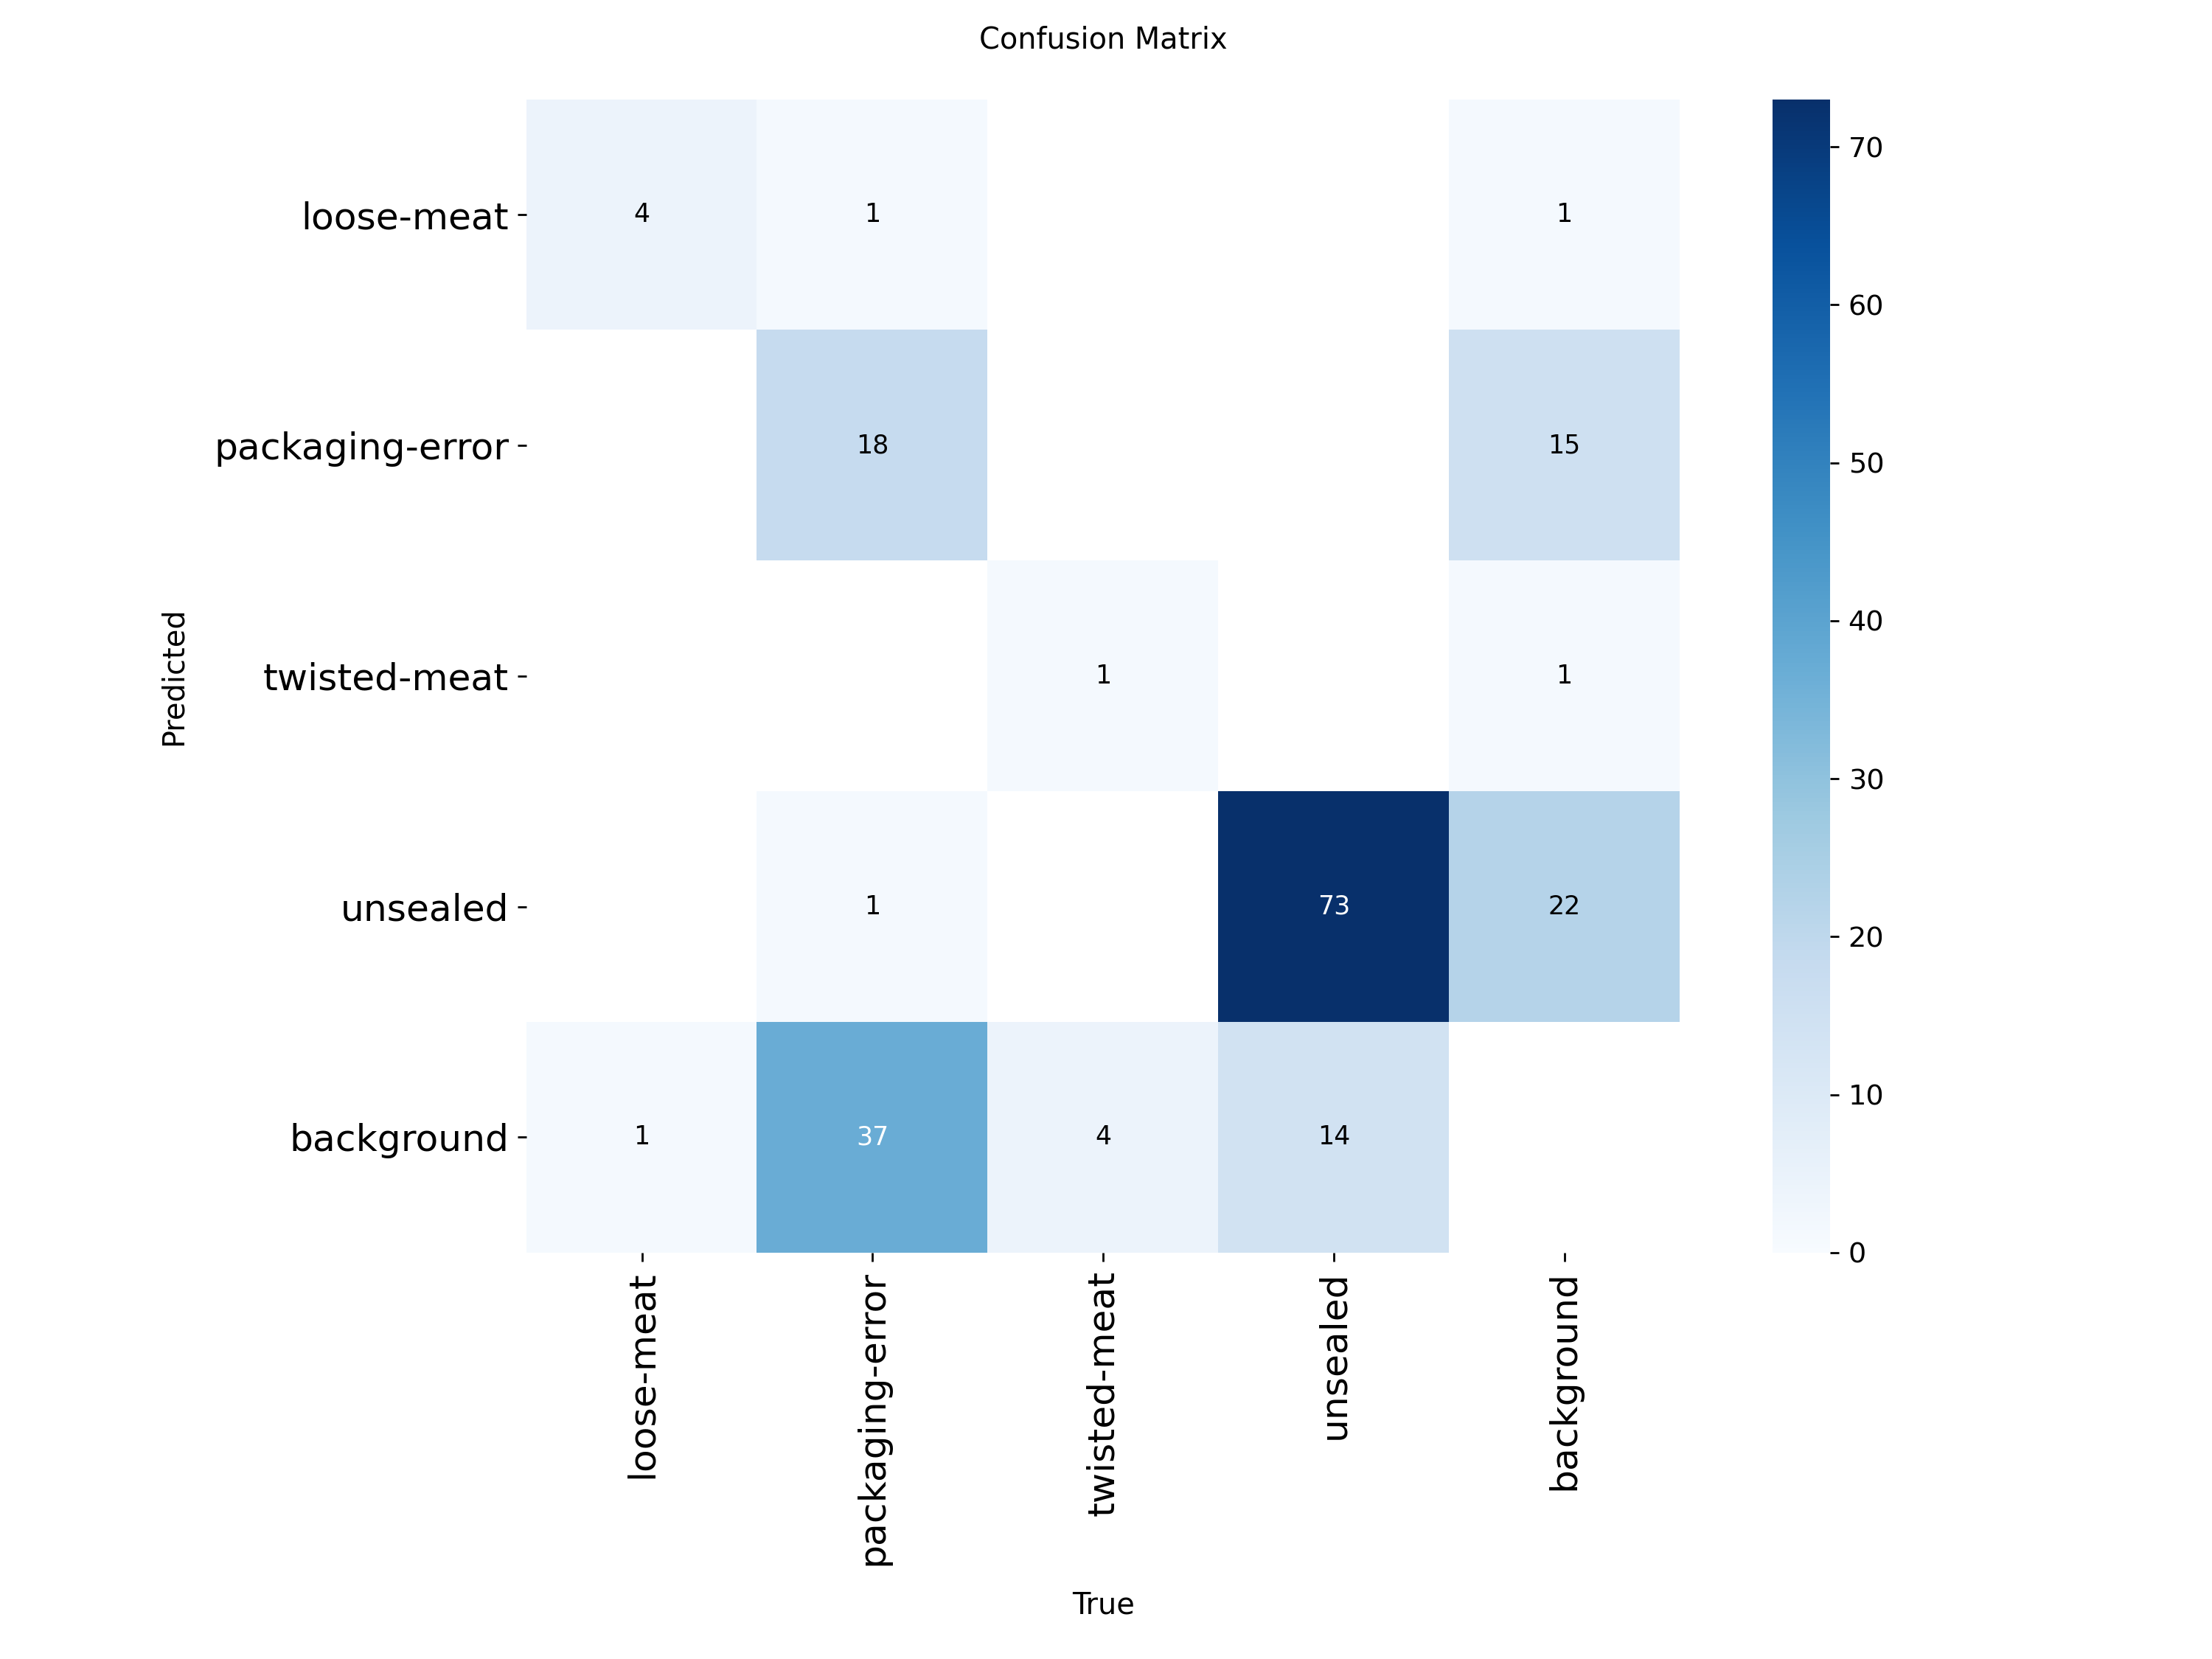

In [ ]:
from PIL import Image
from pathlib import Path

# Inspect V1 validation errors
run_dir = Path(
    "/content/drive/MyDrive/MMA3001_Project/model_runs/"
    "yolov8n_v1_baseline"
)

display(Image.open(run_dir / "confusion_matrix.png"))